## Imports

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading

In [87]:
df_raw = pd.read_csv('../king_ country_ houses_data/king_ country_ houses_aa.csv')

In [88]:
df = df_raw.copy()

## Data description

- id :- It is the unique numeric number assigned to each house being sold
- date :- It is the date on which the house was sold out
- price:- It is the price of house which we have to predict so this is our target variable and aprat from it are our features
- bedrooms :- It determines number of bedrooms in a house
- bathrooms :- It determines number of bathrooms in a bedroom of a house
- sqft_living :- It is the measurement variable which determines the measurement of house in square foot
- sqft_lot : It is also the measurement variable which determines square foot of the lot
- floors: It determines total floors means levels of house
- waterfront : This feature determines whether a house has a view to waterfront 0 means no 1 means yes
- view : This feature determines whether a house has been viewed or not 0 means no 1 means yes
- condition : It determines the overall condition of a house on a scale of 1 to 5
- grade : It determines the overall grade given to the housing unit, based on King County grading system on a scale of 1 to 11
- sqft_above : It determines square footage of house apart from basement
- sqft_basement : It determines square footage of the basement of the house
- yr_built : It detrmines the date of building of the house
- yr_renovated : It detrmines year of renovation of house
- zipcode : It determines the zipcode of the location of the house
- lat : It determines the latitude of the location of the house
- long : It determines the longitude of the location of the house
- sqft_living15 : Living room area in 2015(implies-- some renovations)
- sqft_lot15 : lotSize area in 2015(implies-- some renovations)

## EDA

In [89]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [90]:
df.shape

(21613, 21)

In [91]:
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [92]:
df["zipcode"].unique()

array([98178, 98125, 98028, 98136, 98074, 98053, 98003, 98198, 98146,
       98038, 98007, 98115, 98107, 98126, 98019, 98103, 98002, 98133,
       98040, 98092, 98030, 98119, 98112, 98052, 98027, 98117, 98058,
       98001, 98056, 98166, 98023, 98070, 98148, 98105, 98042, 98008,
       98059, 98122, 98144, 98004, 98005, 98034, 98075, 98116, 98010,
       98118, 98199, 98032, 98045, 98102, 98077, 98108, 98168, 98177,
       98065, 98029, 98006, 98109, 98022, 98033, 98155, 98024, 98011,
       98031, 98106, 98072, 98188, 98014, 98055, 98039], dtype=int64)

### Date

It is the date on which the house was sold out (May 2014 to May 2015)

In [93]:
# ---- Minimal prep needed for the split (adjust as colleague finalizes cleaning) ----
df["date"] = pd.to_datetime(df["date"], format="%Y%m%dT%H%M%S")
df["year_sold"] = df["date"].dt.year
df["month_sold"] = df["date"].dt.month
df.drop(columns=["date", "id"], inplace=True)

In [94]:
df["month_sold"].describe()

count    21613.000000
mean         6.574423
std          3.115308
min          1.000000
25%          4.000000
50%          6.000000
75%          9.000000
max         12.000000
Name: month_sold, dtype: float64

### Price

It is the price of house which we have to predict so this is our TARGET variable and aprat from it are our features

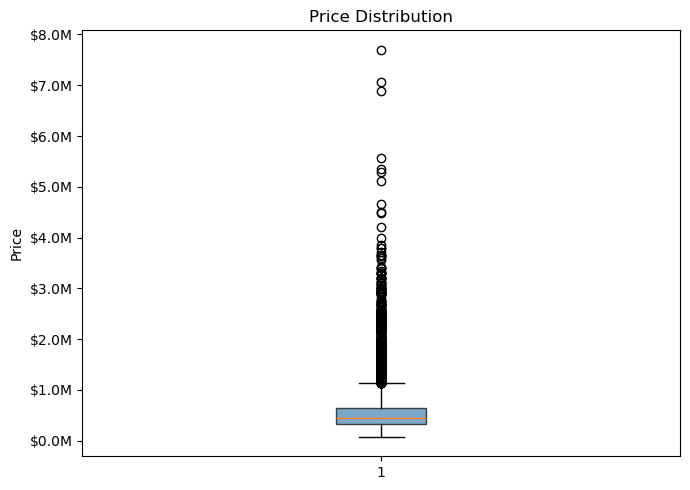

In [95]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.boxplot(df["price"], patch_artist=True,
           boxprops=dict(facecolor="steelblue", alpha=0.7))
ax.set_title("Price Distribution")
ax.set_ylabel("Price")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))

plt.tight_layout()
plt.show()

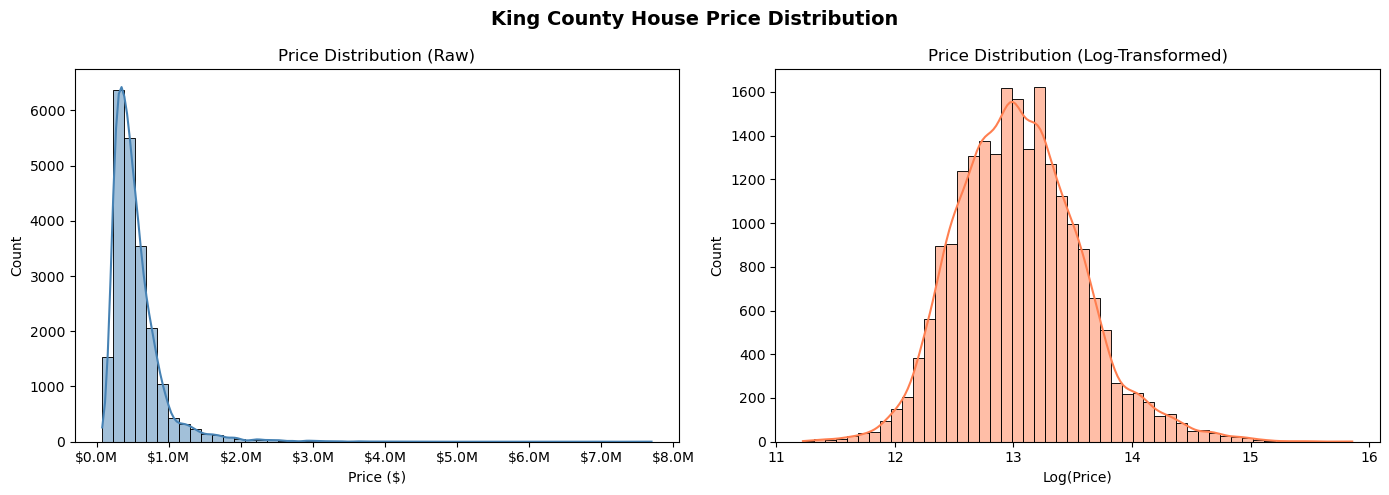

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["price"], bins=50, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Price Distribution (Raw)")
axes[0].set_xlabel("Price ($)")
axes[0].set_ylabel("Count")
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))

sns.histplot(np.log1p(df["price"]), bins=50, kde=True, ax=axes[1], color="coral")
axes[1].set_title("Price Distribution (Log-Transformed)")
axes[1].set_xlabel("Log(Price)")
axes[1].set_ylabel("Count")

plt.suptitle("King County House Price Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Bedrooms

It determines number of bedrooms in a houseBedrooms

In [97]:
df["bedrooms"].unique()

array([ 3,  2,  4,  5,  1,  6,  7,  0,  8,  9, 11, 10, 33], dtype=int64)

In [98]:
df["bedrooms"].value_counts()

bedrooms
3     9824
4     6882
2     2760
5     1601
6      272
1      199
7       38
0       13
8       13
9        6
10       3
11       1
33       1
Name: count, dtype: int64

### Bathrooms

It determines number of bathrooms in a bedroom of a house

In [99]:
df["bathrooms"].nunique()

30

In [100]:
df["bathrooms"].value_counts()

bathrooms
2.50    5380
1.00    3852
1.75    3048
2.25    2047
2.00    1930
1.50    1446
2.75    1185
3.00     753
3.50     731
3.25     589
3.75     155
4.00     136
4.50     100
4.25      79
0.75      72
4.75      23
5.00      21
5.25      13
0.00      10
5.50      10
1.25       9
6.00       6
0.50       4
5.75       4
6.75       2
8.00       2
6.25       2
6.50       2
7.50       1
7.75       1
Name: count, dtype: int64

### Sqft Living

It is the measurement variable which determines the measurement of house in square foot

In [101]:
df["sqft_living"].describe()

count    21613.000000
mean      2079.899736
std        918.440897
min        290.000000
25%       1427.000000
50%       1910.000000
75%       2550.000000
max      13540.000000
Name: sqft_living, dtype: float64

In [102]:
corr_sfl_price = df["sqft_living"].corr(df["price"])
corr_sfl_price.round(4)

0.702

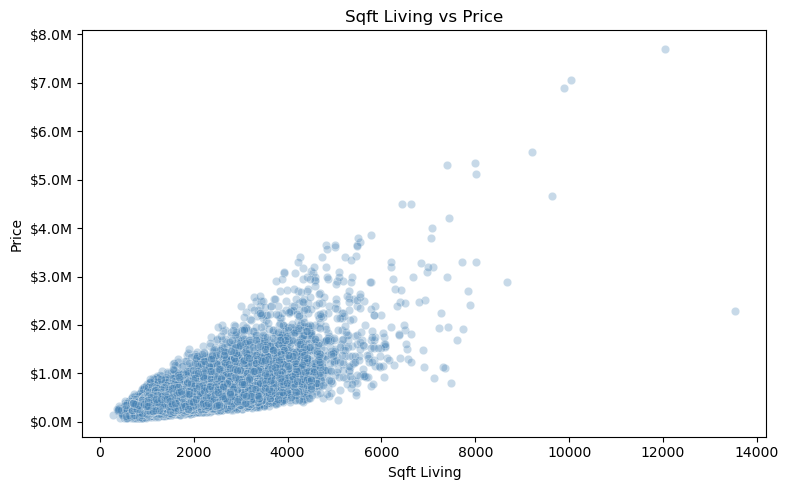

In [103]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(data=df, x="sqft_living", y="price", alpha=0.3, color="steelblue", ax=ax)

ax.set_title("Sqft Living vs Price")
ax.set_xlabel("Sqft Living")
ax.set_ylabel("Price")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))

plt.tight_layout()
plt.show()

### Sqft Lot

It is also the measurement variable which determines square foot of the lot

In [104]:
corr_sflot_price = df["sqft_lot"].corr(df["price"])
corr_sflot_price.round(4)

0.0897

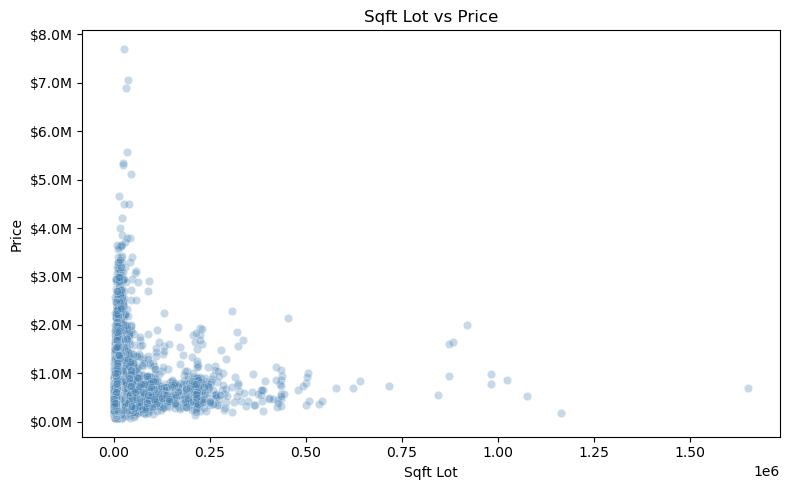

In [105]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(data=df, x="sqft_lot", y="price", alpha=0.3, color="steelblue", ax=ax)

ax.set_title("Sqft Lot vs Price")
ax.set_xlabel("Sqft Lot")
ax.set_ylabel("Price")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))

plt.tight_layout()
plt.show()

### Floors

It determines total floors means levels of house

In [106]:
df["floors"].value_counts()

floors
1.0    10680
2.0     8241
1.5     1910
3.0      613
2.5      161
3.5        8
Name: count, dtype: int64

In [107]:
corr_floor = df["floors"].corr(df["price"])
corr_floor.round(4)

0.2568

### Waterfront

This feature determines whether a house has a view to waterfront 0 means no 1 means yes

In [108]:
df["waterfront"].value_counts()

waterfront
0    21450
1      163
Name: count, dtype: int64

In [109]:
waterfront_corr = df["waterfront"].corr(df["price"])
waterfront_corr

0.26636943403060215

### View

This feature determines whether a house has been viewed or not 0 means no 1 means yes

In [110]:
df["view"].value_counts()

view
0    19489
2      963
3      510
1      332
4      319
Name: count, dtype: int64

In [111]:
view_corr = df["view"].corr(df["price"])
view_corr

0.39729348829450456

### Condition

It determines the overall condition of a house on a scale of 1 (worst condition) to 5 (best condition)

In [112]:
df["condition"].value_counts()

condition
3    14031
4     5679
5     1701
2      172
1       30
Name: count, dtype: int64

In [113]:
avg_price_by_condition = df.groupby("condition")["price"].mean().reset_index()
avg_price_by_condition.columns = ["condition", "avg_price"]
avg_price_by_condition.round(2)

,condition,avg_price
0,1,334431.67
1,2,327287.15
2,3,542012.58
3,4,521200.39
4,5,612418.09


In [114]:
condition_corr = df["condition"].corr(df["price"])
condition_corr

0.0363617891289975

### Grade

It determines the overall grade given to the housing unit, based on King County grading system on a scale of 1 (worst) to 13 (best)

In [115]:
df["grade"].value_counts()

grade
7     8981
8     6068
9     2615
6     2038
10    1134
11     399
5      242
12      90
4       29
13      13
3        3
1        1
Name: count, dtype: int64

In [116]:
avg_price_by_grade = df.groupby("grade")["price"].mean().reset_index()
avg_price_by_grade.columns = ["grade", "avg_price"]
avg_price_by_grade.round(2)

,grade,avg_price
0,1,142000.00
1,3,205666.67
2,4,214381.03
3,5,248523.97
4,6,301919.64
5,7,402590.26
6,8,542852.77
7,9,773513.19
8,10,1071771.07
9,11,1496841.73


### Yr_built

It detrmines the date of building of the house

### Yr_renovated

It detrmines year of renovation of house

### Zipcode

It determines the zipcode of the location of the house

### Correlation

In [118]:
# df_corr = 

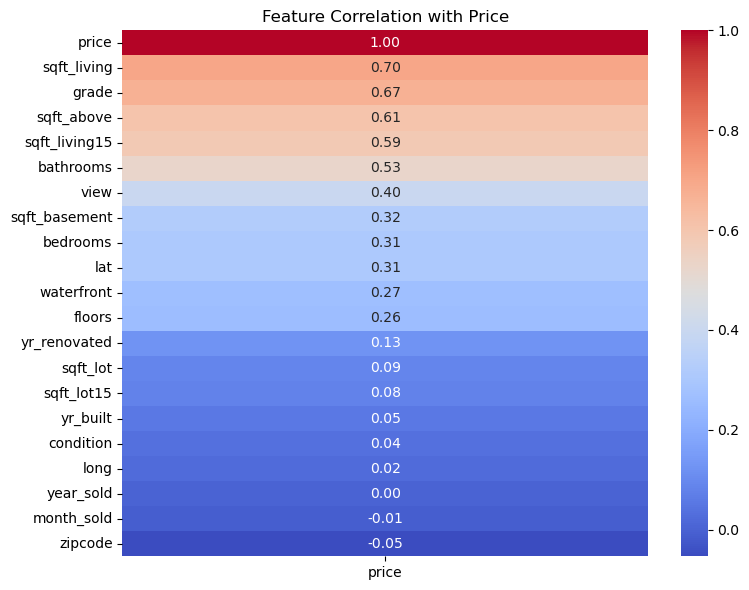

In [119]:
fig, ax = plt.subplots(figsize=(8, 6))

price_corr = df.corr()[["price"]].sort_values("price", ascending=False)

sns.heatmap(price_corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax)

ax.set_title("Feature Correlation with Price")
plt.tight_layout()
plt.show()

## Models

### Train/Test Split

In [120]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns="price")
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")

Train size: (17290, 20)
Test size:  (4323, 20)


### Baseline Model: Linear Regression

In [134]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Train Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Predictions
y_train_pred = lr.predict(X_train_scaled)
y_test_pred = lr.predict(X_test_scaled)

# Evaluate performance
print("Train Performance:")
print(f"R2:   {r2_score(y_train, y_train_pred):.4f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_train, y_train_pred)):,.2f}")
print(f"MAE:  ${mean_absolute_error(y_train, y_train_pred):,.2f}")
print()
print("Test Performance:")
print(f"R2:   {r2_score(y_test, y_test_pred):.4f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_test, y_test_pred)):,.2f}")
print(f"MAE:  ${mean_absolute_error(y_test, y_test_pred):,.2f}")

Train Performance:
R2:   0.7021
RMSE: $203,269.73
MAE:  $127,246.87

Test Performance:
R2:   0.6963
RMSE: $190,042.08
MAE:  $121,580.87


### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Train Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=0, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

# Predictions
y_train_pred = rf.predict(X_train_scaled)
y_test_pred = rf.predict(X_test_scaled)

# Evaluate performance
print("Train Performance")
print(f"R2:   {r2_score(y_train, y_train_pred):.4f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_train, y_train_pred)):,.2f}")
print(f"MAE:  ${mean_absolute_error(y_train, y_train_pred):,.2f}")
print()
print("Test Performance")
print(f"R2:   {r2_score(y_test, y_test_pred):.4f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_test, y_test_pred)):,.2f}")
print(f"MAE:  ${mean_absolute_error(y_test, y_test_pred):,.2f}")

Train Performance
R2:   0.9827
MSE: $48,984.25
MAE:  $25,821.77

Test Performance
R2:   0.8922
RMSE: $113,208.47
MAE:  $64,522.57


### XGBoost

In [135]:
from xgboost import XGBRegressor

# Train XGBoost
xgb = XGBRegressor(n_estimators=100, random_state=0, n_jobs=-1)
xgb.fit(X_train_scaled, y_train)

# Predictions
y_train_pred = xgb.predict(X_train_scaled)
y_test_pred = xgb.predict(X_test_scaled)

# Evaluate performance
print("Train Performance")
print(f"R2:   {r2_score(y_train, y_train_pred):.4f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_train, y_train_pred)):,.2f}")
print(f"MAE:  ${mean_absolute_error(y_train, y_train_pred):,.2f}")
print(f" ")
print("Test Performance")
print(f"R2:   {r2_score(y_test, y_test_pred):.4f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_test, y_test_pred)):,.2f}")
print(f"MAE:  ${mean_absolute_error(y_test, y_test_pred):,.2f}")

Train Performance
R2:   0.9783
RMSE: $54,900.83
MAE:  $39,102.38
 
Test Performance
R2:   0.8956
RMSE: $111,442.84
MAE:  $63,831.28


### Ensemble: Stacking

- Layer 1 (Base models): RandomForest, XGBoost and Gradient Boosting each make predictions independently
- Layer 2 (Meta-model): Linear Regression learns how to best combine those predictions into a final output
- cv = 5  base models are trained using 5-fold cross-validation to prevent leakage into the meta-model

In [136]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

# Base models
base_models = [
    ("random_forest", RandomForestRegressor(n_estimators=100, random_state=0, n_jobs=-1)),
    ("xgboost", XGBRegressor(n_estimators=100, random_state=0, n_jobs=-1)),
    ("gradient_boosting", GradientBoostingRegressor(n_estimators=100, random_state=0))
]

# Meta-model
meta_model = LinearRegression()

# Train Stacking Model
stacking = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    n_jobs=-1
)
stacking.fit(X_train_scaled, y_train)

# Predictions
y_train_pred = stacking.predict(X_train_scaled)
y_test_pred = stacking.predict(X_test_scaled)

# Evaluate performance
print("Train Performance")
print(f"R2:   {r2_score(y_train, y_train_pred):.4f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_train, y_train_pred)):,.2f}")
print(f"MAE:  ${mean_absolute_error(y_train, y_train_pred):,.2f}")
print(f" ")
print("Test Performance ")
print(f"R2:   {r2_score(y_test, y_test_pred):.4f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_test, y_test_pred)):,.2f}")
print(f"MAE:  ${mean_absolute_error(y_test, y_test_pred):,.2f}")

Train Performance
R2:   0.9741
RMSE: $59,954.66
MAE:  $41,537.42
 
Test Performance 
R2:   0.9021
RMSE: $107,910.81
MAE:  $62,647.40


### CatBoost

In [138]:
from catboost import CatBoostRegressor

# Define categorical features
cat_features = ["zipcode", "waterfront", "view", "condition"]

# Train CatBoost using UNSCALED data
catboost = CatBoostRegressor(
    iterations=100,
    random_seed=0,
    verbose=False
)
catboost.fit(X_train, y_train, cat_features=cat_features)

# Predictions
y_train_pred = catboost.predict(X_train)
y_test_pred = catboost.predict(X_test)

# Evaluate performance
print("---- Train Performance ----")
print(f"R²:   {r2_score(y_train, y_train_pred):.4f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_train, y_train_pred)):,.2f}")
print(f"MAE:  ${mean_absolute_error(y_train, y_train_pred):,.2f}")

print("\n---- Test Performance ----")
print(f"R²:   {r2_score(y_test, y_test_pred):.4f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_test, y_test_pred)):,.2f}")
print(f"MAE:  ${mean_absolute_error(y_test, y_test_pred):,.2f}")

---- Train Performance ----
R²:   0.9519
RMSE: $81,684.70
MAE:  $55,353.74

---- Test Performance ----
R²:   0.9028
RMSE: $107,493.92
MAE:  $63,407.37
